In [242]:
import sklearn.cluster as sk
import itertools
import sys
import matplotlib.pyplot as plt
#from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from pathlib import Path
import geopandas as gpd
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit
# Bookkeeping of important path in the project
data_dir = Path().cwd().parent/Path("data")
data_city = data_dir / "cities"
data_map = data_dir / "map"
out_dir = Path().cwd().parent/Path("out")
plot_dir = out_dir / Path("plot")

In [260]:
name = "Austria" #name of the system considered
name_random = f"Random{name}" #How the name of the random catalo will be saved
threshold = 1 # minimal number of inhabitants for the city to be considered
N_run = 1 # number of random catalog generated for computing the 2PCF
size = 7000 #number of points each random catalog has
k = 2  #number of time the 2PCF computing process is repeated to estimate variance
rmax = None #maximal distance between two points considered, if None, taken the max from data
scale = "log" #scale at which to bin the data, recommended "log"
nbins = 20 # number of bins to consider in the computation of 2PCF (betweem rmin and rmax)

In [261]:
##Preprocessing
crs = mtpc.crs_selector(name) # Coordinate reference system of the country considered
path_city = data_city / f"{name}_cities.csv" #Path of the cities 
path_border = data_map / f"{name}.geojson" # Path of the multipolygon of the territory of the country
gdf_city = mtpc.load_df_to_gdf(path_city,threshold) # Geopandas of the dataset
gdf_edge = gpd.read_file(path_border) #Geopandas of the polygon border of the dataset
gdf_projected = gdf_city.to_crs(crs) # Projection in the right coordinate system
coord = gdf_projected.get_coordinates() # Coordinates of the points in dataset

In [262]:
gdf_projected

,Unnamed: 0,city,city_ascii,city_alt,lat,lng,country,iso2,iso3,admin_name,admin_name_ascii,admin_code,admin_type,capital,density,population,population_proper,ranking,timezone,same_name,id,geometry
0,1668896,Vienna,Vienna,Vindobona|Vindobna|Wien|Vienne|VideÅ|BÃ©cs|Du...,48.2083,16.3725,Austria,AT,AUT,Wien,Wien,AT-9,state,primary,4757.7,2223236.0,1973403.0,1.0,Europe/Vienna,False,1.040262e+09,POINT (625766.58 483144.818)
1,1668897,Graz,Graz,Gratz,47.0708,15.4386,Austria,AT,AUT,Steiermark,Steiermark,AT-6,state,admin,2293.9,292630.0,292630.0,2.0,Europe/Vienna,False,1.040185e+09,POINT (559836.943 354464.329)
2,1668898,Linz,Linz,NaN,48.3058,14.2864,Austria,AT,AUT,OberÃ¶sterreich,Oberosterreich,AT-4,state,admin,2189.4,210165.0,210165.0,2.0,Europe/Vienna,False,1.040261e+09,POINT (470682.551 490001.384)
3,1668899,Lochau,Lochau,NaN,47.5167,9.7500,Austria,AT,AUT,Vorarlberg,Vorarlberg,AT-8,state,NaN,559.6,200000.0,5747.0,2.0,Europe/Vienna,False,1.040573e+09,POINT (130292.334 408076.021)
4,1668900,Salzburg,Salzburg,NaN,47.8000,13.0450,Austria,AT,AUT,Salzburg,Salzburg,AT-5,state,admin,2361.3,155021.0,155021.0,2.0,Europe/Vienna,False,1.040312e+09,POINT (378407.138 433383.861)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2254,1671150,Mitteregg,Mitteregg,NaN,47.3811,10.7278,Austria,AT,AUT,Tirol,Tirol,AT-7,state,NaN,1.5,18.0,18.0,4.0,Europe/Vienna,False,1.040937e+09,POINT (203350.637 390082.57)
2255,1671151,Hinteregg,Hinteregg,NaN,47.0181,12.5160,Austria,AT,AUT,Tirol,Tirol,AT-7,state,NaN,16.9,17.0,17.0,4.0,Europe/Vienna,False,1.040310e+09,POINT (337878.02 346768.706)
2256,1671152,Raneburg,Raneburg,NaN,47.0681,12.5289,Austria,AT,AUT,Tirol,Tirol,AT-7,state,NaN,16.9,16.0,16.0,4.0,Europe/Vienna,False,1.040377e+09,POINT (338915.985 352315.043)
2257,1671153,Linden,Linden,NaN,48.2319,14.7765,Austria,AT,AUT,OberÃ¶sterreich,Oberosterreich,AT-4,state,NaN,37.0,10.0,10.0,4.0,Europe/Vienna,True,1.040348e+09,POINT (507179.077 482347.963)


In [263]:
def compute_DD_SP(gdf_projected):
    coord_data = gdf_projected.get_coordinates().to_numpy()
    DD = distance.pdist(coord_data).astype(np.float32)#np.triu(distance.cdist(coord_data,coord_data)).astype(np.int32)
    #DD = np.ravel(DD)
    #DD = DD[DD != 0]
    return DD

def compute_one_DR_RR_SP(gdf_projected,gdf_edge, size, crs):
    coord_random = generate_random_point(gdf_edge, size, crs)#generate_sobol_point(gdf_edge, size, crs)#generate_random_point(gdf_edge, size, crs)
    coord_data = gdf_projected.get_coordinates().to_numpy()
    DR = distance.cdist(coord_data,coord_random).astype(np.float32)
    DR = np.ravel(DR)
    DR = DR[DR != 0]
    RR = distance.pdist(coord_random).astype(np.float32)#np.triu(distance.cdist(coord_random,coord_random)).astype(np.int32)
    #RR = np.ravel(RR)
    #RR = RR[RR != 0]
    return DR,RR#,len(coord_random)

def compute_two_point_correlation_2019_metadata(gdf_projected,gdf_edge,crs,N_run,Nr_prime,rmin,Nd,rmax,scale,nbins=20):
    Nr = Nr_prime*N_run
    #Nr = len(gdf_projected)
    metadata_min = np.min(population)
    metadata_max = np.max(population)
    meta_edges = np.logspace(np.log10(metadata_min), np.log10(metadata_max), nbins)
    for h in range(len(meta_edges)-1):
        
    DD = compute_DD_SP(gdf_projected)
    DR,RR = compute_one_DR_RR_SP(gdf_projected,gdf_edge, Nr_prime, crs)
    for i in range(N_run-1):
        print(i)
        DR_i,RR_i = compute_one_DR_RR_SP(gdf_projected,gdf_edge, Nr_prime, crs)
        RR = np.concatenate((RR,RR_i))
        DR = np.concatenate((DR,DR_i))
    if not rmin:
        rmin = compute_rmin(gdf_projected)
    if rmax:
        rmax = rmax
    else:
        rmax = np.max(DD)+1#find_rmax_meaningful(gdf_edge,crs,100000)
    if scale =="log":
        r_edges = np.logspace(np.log10(rmin), np.log10(rmax), nbins)
    elif scale == "lin":
        r_edges = np.linspace(rmin,rmax,nbins)
    hist_DD = binning_data(DD,nbins,r_edges)
    print("max DD", np.max(DD))
    print("min DD",np.min(DD))
    #hist_DD = hist_DD[0:(len(hist_DD)-1)]
    del DD
    hist_DR = binning_data(DR,nbins,r_edges)
    del DR
    hist_RR = binning_data(RR,nbins,r_edges)
    print("maxRR",np.max(RR))
    print("minRR",np.min(RR))
    del RR
    print(rmin,rmax)
    if len(hist_RR) == len(hist_DD)+1:
        hist_RR = hist_RR[0:(len(hist_RR)-1)]
    if len(hist_DR) == len(hist_DD)+1:
        hist_DR = hist_DR[0:(len(hist_DR)-1)]
    print(np.sum(hist_DD)*(2/(Nd*(Nd-1))))
    print(np.sum(hist_DR)/((Nd*(Nr))))
    print(np.sum(hist_RR)*(2/(Nr*(Nr_prime-1))))
    xi= compute_LS_correlation_2019(hist_DD,hist_DR,hist_RR,Nd,Nr_prime,Nr)
    return r_edges,xi

IndentationError: expected an indented block after 'for' statement on line 25 (2914654203.py, line 27)

In [264]:
metadata_name = "density"
population = gdf_projected[metadata_name].values

In [265]:
from scipy.spatial import distance
def compute_DD_meta(gdf_projected_meta,gdf_projected_meta_prime):
    coord_meta = gdf_projected_meta.get_coordinates().to_numpy()
    coord_meta_prime = gdf_projected_meta_prime.get_coordinates().to_numpy()
    DD = np.triu(distance.cdist(coord_meta,coord_meta_prime)).astype(np.int32)
    DD = np.ravel(DD)
    DD = DD[DD != 0]
    return DD

def compute_DR_meta(gdf_projected_meta,coord_random):
    coord_meta = gdf_projected_meta.get_coordinates().to_numpy()
    #coord_random = gpd_random.get_coordinates().to_numpy()
    #DR = np.triu(distance.cdist(coord_meta,coord_meta_random_prime)).astype(np.int32)
    DR = distance.cdist(coord_meta,coord_random).astype(np.int32)
    DR = np.ravel(DR)
    DR = DR[DR != 0]
    RR = np.triu(distance.cdist(coord_random,coord_random)).astype(np.int32)
    RR = np.ravel(RR)
    RR = RR[RR != 0]
    return DR,RR
    
# NEED TO ADAPT TO ANY NUMBER OF POINTS 
def generate_random_geopandas_with_pop(gdf_edge,gdf_projected,crs,size):
    N = len(gdf_projected)
    sample = gdf_edge.sample_points(size)
    gdf_random = sample.to_crs(crs)
    sample = sample.explode(ignore_index=True)
    rng = np.random.default_rng()
    population_random=rng.choice(gdf_projected[metadata_name].values,size=size)
    df_pop_random = pd.Series(population_random)
    gpd_rand_pop = try_panda = pd.concat([sample,df_pop_random],keys=["geometry", "population"],axis=1,ignore_index=True)
    gpd_rand_pop[0] = gpd_rand_pop[0].to_crs(crs)
    return gpd_rand_pop

In [266]:
def compute_two_point_correlation_metadata(gdf_projected,gdf_edge,crs,N_run,Nr_prime,rmin,Nd,rmax,scale,nbins_metadata,metadata_name,nbins=20):
    population = np.sort(gdf_projected[metadata_name].values)
    meta_edges = [population[0]]
    for i in range(1,nbins_meta):
        meta_edges.append(population[i*len(population)// (nbins_meta)])
    meta_edges.append(population[-1])
   #min_pop = np.min(population)
    #max_pop = np.max(population)
    #meta_edges=[7.00000000e+00, 4.77595855e+02, 3.25854001e+04, 2.22323600e+06]
    #print(meta_edges)
    gpd_random = mtpc.generate_random_point(gdf_edge,size,crs,check_gpd=False)#generate_random_geopandas_with_pop(gdf_edge,gdf_projected,crs,size)
    l_N = np.zeros([nbins_meta,nbins_meta])
    DD,DR,RR = np.zeros([nbins_meta,nbins_meta],dtype=list),np.zeros([nbins_meta,nbins_meta],dtype=list),np.zeros([nbins_meta,nbins_meta],dtype=list)
    for h in range(len(meta_edges)-1):
        gpd_random = mtpc.generate_random_point(gdf_edge,size,crs,check_gpd=False)
        gdf_projected_low = gdf_projected[(gdf_projected[metadata_name] > meta_edges[h]) & (gdf_projected[metadata_name] <= meta_edges[h+1])]
        for h_prime in range(len(meta_edges)-1):
            if h_prime != h:
                print("step hprime",h_prime)
                gdf_projected_high = gdf_projected[(gdf_projected[metadata_name] > meta_edges[h_prime]) & (gdf_projected[metadata_name] <= meta_edges[h_prime+1])]
                gdf_projected_interval = pd.concat([gdf_projected_low,gdf_projected_high])
            else:
                gdf_projected_interval = gdf_projected_low
            #print(h,h_prime)
            l_N[h][h_prime] = len(gdf_projected_interval)
            DD[h][h_prime]=mtpc.compute_DD_SP(gdf_projected_interval)
            DR_i,RR_i = compute_DR_meta(gdf_projected_interval,gpd_random)
            DR[h][h_prime]= DR_i
            RR[h][h_prime]= RR_i
                
            #for i in range(N_run-1):
               # print("step N_run",i)
                #gpd_random = mtpc.generate_random_point(gdf_edge,size,crs,check_gpd=False)
                #DR_i,RR_i = compute_DR_meta(gdf_projected_interval,gpd_random)
                #DR[h][h_prime]= np.concatenate((RR[h][h_prime],RR_i))
                #RR[h][h_prime] = np.concatenate((DR[h][h_prime],DR_i))
    rmin = None
    if not rmin:
        rmin = mtpc.compute_rmin(gdf_projected)
    if rmax:
        rmax = rmax
    else:
        rmax = np.max(DD)+1#find_rmax_meaningful(gdf_edge,crs,100000)
    scale="log"
    if scale =="log":
        r_edges = np.logspace(np.log10(rmin), np.log10(rmax), nbins)
    elif scale == "lin":
        r_edges = np.linspace(rmin,rmax,nbins)
    hist_DD = np.zeros([nbins_meta,nbins_meta],dtype=list)
    hist_DR = np.zeros([nbins_meta,nbins_meta],dtype=list)
    hist_RR = np.zeros([nbins_meta,nbins_meta],dtype=list)
    xi = np.zeros([nbins_meta,nbins_meta],dtype=list)
    
    sum_DD,sum_DR,sum_RR = 0,0,0
    #N_run = 1
    Nd= len(gdf_projected)
    Nr_prime = size
    Nr=Nr_prime*N_run
    
    for i in range(len(DD)):
        sum_DD = 0
        sum_DR = 0
        sum_RR = 0
        for j in range(len(DD)):
            Nd = l_N[i][j]
            hist_DD[i][j] = mtpc.binning_data(DD[i][j],nbins,r_edges)
            hist_DR[i][j] = mtpc.binning_data(DR[i][j],nbins,r_edges)
            hist_RR[i][j] = mtpc.binning_data(RR[i][j],nbins,r_edges)
            hist_RR[i][j] = hist_RR[i][j] + 1 #to avoid having division by zero in the computation of xi
            #print("DD ",hist_DD[i][j].shape)
            if len(hist_RR[i][j]) == len(hist_DD[i][j])+1:
                hist_RR[i][j] = hist_RR[i][j][0:(len(hist_RR[i][j])-1)]
            if len(hist_DR[i][j]) == len(hist_DD[i][j])+1:
                hist_DR[i][j] = hist_DR[i][j][0:(len(hist_DR[i][j])-1)]
            #print(i,j)
            sum_DD += np.sum(hist_DD[i][j])*(2/(Nd*(Nd-1)))
            sum_DR += np.sum(hist_DR[i][j])/((Nd*(Nr)))
            sum_RR += np.sum(hist_RR[i][j])*(2/(Nr*(Nr_prime)))
            print("DD",sum_DD)
            print("DR", sum_DR)
            print("RR",sum_RR)
            xi[i][j] = mtpc.compute_LS_correlation_2019(hist_DD[i][j],hist_DR[i][j],hist_RR[i][j],Nd,Nr_prime,Nr)
    return r_edges,xi,l_N

In [267]:
def PCF_with_variance_meta(gdf_projected,gdf_edge,crs,N_run,size,k,rmax,scale,nbins,nbins_metadata,metadata_name,rmin=False):
    """Compute k different instances of the 2 points correlation function for gdf_projected system, 
    to build a statistical varaince on the 2 pcf. For each instance the system is compared to N_run random catalog
    with an effective size of N_run*size
    Input:
        gdf_projected: geopandas of the system of points we are interested in in the right crs
        gdf_edge: geopandas of the border of the system of points
        crs: str of coordinate reference system
        N_run: int of the number of time a random catalog is generated to compute 2pcf
        size: int size in number of points of each random catalog
        k:  int number of times to cpmpute the 2pcf to build a statistical variance
        rmax: float maximal value below which the 2pcf will be computed
        scale: str linear or logscale at which the distances will be binned
        nbins: int number of bins between rmin and rmax
    Output:
        r-edges: list of distance bins with length equals nbins
        l_xi: array of shape (nbins,k) that stor for each distance bin the value of the 2pcf
    """
    l_xi = []
    #rmin = 0
    if len(gdf_projected) == 1:
        number_point = len(gdf_projected.explode())
    else:
        number_point = len(gdf_projected)
    for i in range(k):
        r_edges,xi,l_N = compute_two_point_correlation_metadata(gdf_projected,gdf_edge,crs,N_run,size,rmin,number_point,rmax,scale,nbins_metadata,metadata_name,nbins=nbins)
        l_xi.append(xi)
    xi = np.mean(l_xi,axis=0)
    return r_edges,np.array(l_xi),l_N
    
metadata_name = "density"    
nbins_meta = 2  
rmax= np.max(mtpc.compute_DD_SP(gdf_projected))+1
r_edges,l_xi,l_N=PCF_with_variance_meta(gdf_projected,gdf_edge,crs,N_run,size,k,rmax,scale,nbins,nbins_meta,metadata_name,rmin=False)

step hprime 1
step hprime 0
DD 1.0
DR 0.9999993673288624
RR 0.9998568163265307
DD 2.0
DR 1.9999987346577248
RR 1.9997136326530613
DD 0.9999999999999999
DR 0.9999989877261799
RR 0.9998558775510205
DD 2.0
DR 1.9999982285208149
RR 1.999711755102041
step hprime 1
step hprime 0
DD 1.0
DR 0.9999987346577249
RR 0.9998560000000001
DD 2.0
DR 1.999997406048336
RR 1.9997120000000002
DD 0.9999999999999999
DR 0.9999990509932937
RR 0.9998562448979592
DD 2.0
DR 1.9999982917879287
RR 1.9997124897959184


In [268]:
def plot_2pcf(r_edges,l_xi,scale,population,nbins_meta,off_diagonal=False):
    """Plot and save the 2pcf store in load_file"""
    i=1
    fig, ax = plt.subplots(figsize=(10,5))
    sns.set(style="whitegrid")
    meta_edges = [population[0]]
    for i in range(1,nbins_meta):
        meta_edges.append(population[i*len(population)// (nbins_meta)])
    meta_edges.append(population[-1])
    #meta_edges=[7.00000000e+00, 4.77595855e+02, 3.25854001e+04, 2.22323600e+06]
    xi = np.mean(l_xi,axis=0)
    error= np.var(l_xi,axis=0,ddof=1)
    print(error[0][0])
    for i in range(len(error)):
        for j in range(len(error[0])):
            error[i][j] = np.sqrt(error[i][j])
    #error = np.std(l_xi,axis=0)
    #if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
     #   xi = xi[0:-1]
     #   error = error[0:-1]
    color = sns.color_palette("viridis")[0]
    
    #r_edges = r_edges[1:]
    #xi = xi[1:]
    #error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    if off_diagonal == False:
        for i in range(len(xi)):
            color = sns.color_palette("viridis")[i%5]
            if i >=4:
                color = sns.color_palette("magma_r")[i%5]
            width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
            ax.bar(r_edges,xi[i][i],width=width,align="center",edgecolor="black",color=color,alpha=0.75,label=f"{meta_edges[i]}")
            plt.errorbar(r_edges, xi[i][i], yerr=error[i][i], fmt="o", color="r",ms=1)
            title = "2 points correlation function" 
            plt.title(title)
            plt.ylabel(r"$\xi(r)$")
            plt.xlabel(r"$r$ (meters)")
    else:
        for i in range(len(xi)):
            for j in range(i):
                if i!=j:
                    color = sns.color_palette("viridis")[j%5]
                    if j >=4:
                        color = sns.color_palette("magma_r")[j%5]
                    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
                    ax.bar(r_edges,xi[i][j],width=width,align="center",edgecolor="black",color=color,alpha=0.75,label=f"[{meta_edges[i]},{meta_edges[j]}")
                    plt.errorbar(r_edges, xi[i][j], yerr=error[i][j], fmt="o", color="r",ms=1)
                    title = "2 points correlation function" 
                    plt.title(title)
                    plt.ylabel(r"$\xi(r)$")
                    plt.xlabel(r"$r$ (meters)")
            
    if scale == "lin":
        plt.xscale("linear")
    else:
        plt.xscale(scale)
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

In [225]:
color

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [269]:
population = np.sort(gdf_projected[metadata_name].values)

In [270]:
meta_edges = [population[0]]
for i in range(1,nbins_meta):
    meta_edges.append(population[i*len(population)// (nbins_meta)])
meta_edges.append(population[-1])

In [271]:
meta_edges

[1.4, 66.2, 4757.7]

In [272]:
r_edges

array([  3109.65816089,   4090.89678175,   5381.76082805,   7079.95120767,
         9313.99790969,  12252.98798215,  16119.36312917,  21205.75553234,
        27897.13613954,  36699.95174666,  48280.456154  ,  63515.13654646,
        83557.05169082, 109923.10285211, 144608.84265454, 190239.51136115,
       250268.73197087, 329239.90265831, 433130.07041994, 569802.3125    ])

[1.43867880e-04 2.96690586e-03 3.10959114e-04 4.10894240e-05
 7.29761632e-07 3.25174524e-04 3.62724658e-07 4.23532261e-04
 2.38306486e-04 1.06679622e-06 4.23926774e-05 8.78238340e-06
 1.14309630e-05 2.39324806e-06 3.50527967e-07 4.33677865e-06
 8.59676577e-06 5.65931109e-06 3.95441073e-07 1.26375627e-04]


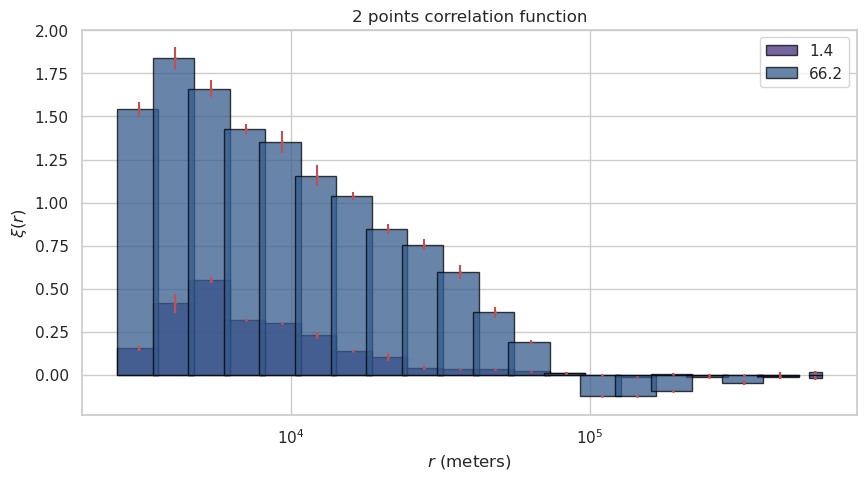

[1.43867880e-04 2.96690586e-03 3.10959114e-04 4.10894240e-05
 7.29761632e-07 3.25174524e-04 3.62724658e-07 4.23532261e-04
 2.38306486e-04 1.06679622e-06 4.23926774e-05 8.78238340e-06
 1.14309630e-05 2.39324806e-06 3.50527967e-07 4.33677865e-06
 8.59676577e-06 5.65931109e-06 3.95441073e-07 1.26375627e-04]


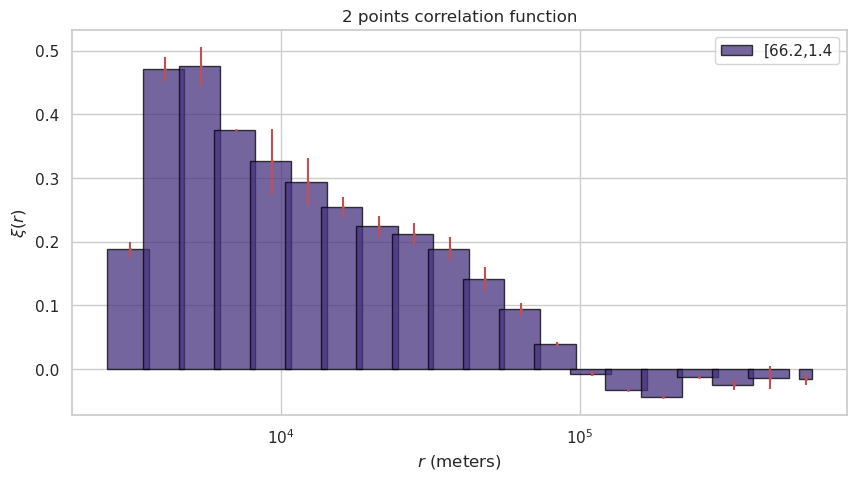

In [273]:
plot_2pcf(r_edges,l_xi,scale,population,nbins_meta,off_diagonal=False)
plot_2pcf(r_edges,l_xi,scale,population,nbins_meta,off_diagonal=True)

In [121]:
l_N

array([[253., 503., 503., 505., 504., 503., 504., 504., 503.],
       [503., 250., 500., 502., 501., 500., 501., 501., 500.],
       [503., 500., 250., 502., 501., 500., 501., 501., 500.],
       [505., 502., 502., 252., 503., 502., 503., 503., 502.],
       [504., 501., 501., 503., 251., 501., 502., 502., 501.],
       [503., 500., 500., 502., 501., 250., 501., 501., 500.],
       [504., 501., 501., 503., 502., 501., 251., 502., 501.],
       [504., 501., 501., 503., 502., 501., 502., 251., 501.],
       [503., 500., 500., 502., 501., 500., 501., 501., 250.]])

In [274]:
def find_cross_2pcf(r_edges,l_xi,l_N):
    xi = np.mean(l_xi,axis=0)
    cross_xi = np.zeros_like(l_xi)
    for h in range(len(l_xi)):
        for i in range(len(xi)):
            for j in range(len(xi)):
                if i!=j:
                    cross_xi[h][i][j] = (((l_N[i][i]+l_N[j][j])**2)*l_xi[h][i][j]-l_N[i][i]*l_N[i][i]*l_xi[h][i][i]-l_N[j][j]*l_N[j][j]*l_xi[h][j][j])/(2*(l_N[i][i]*l_N[j][j]))
                    
    return cross_xi

In [275]:
cross_xi = find_cross_2pcf(r_edges,l_xi,l_N)

0.0


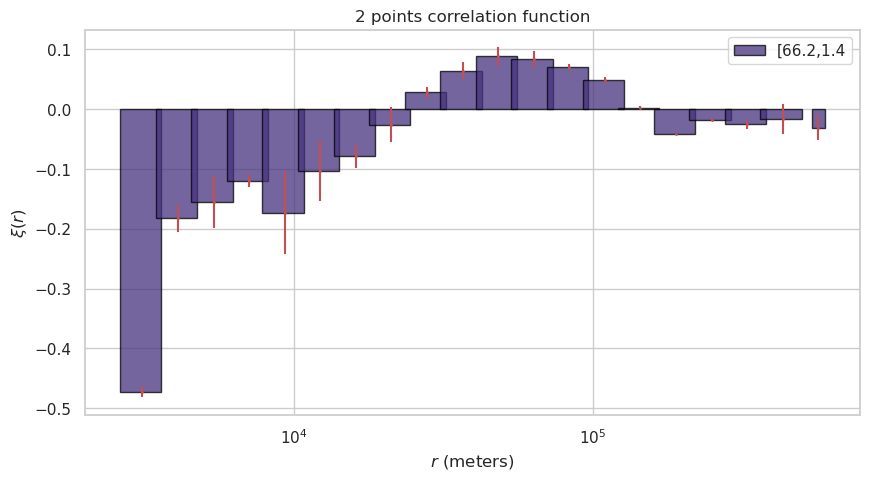

In [276]:
plot_2pcf(r_edges,cross_xi,scale,population,nbins_meta,off_diagonal=True)

In [321]:
meta_edges

[19.0, 1847.0, 4653.0, 8229.0, 12769.0, 21353.0, 1235192.0]

In [352]:
population

array([7.000000e+00, 1.000000e+01, 1.600000e+01, ..., 2.101650e+05,
       2.926300e+05, 2.223236e+06])

In [408]:
min_pop = np.min(population)
max_pop = np.max(population)
lol=np.logspace(np.log10(min_pop),np.log10(max_pop),5)

In [409]:
lol

array([7.00000000e+00, 1.66176620e+02, 3.94495272e+03, 9.36512729e+04,
       2.22323600e+06])

In [410]:
len(population[population > 9.36512729e+04])

7

In [292]:
from scipy.optimize import curve_fit
def power_law(r, gamma,r0):
    """The power law form of the SP model"""
    model = (r/r0)**(-gamma)
    return model
i,j = 1,1
a,b = 1,13 #the two extremal index between which fitting the SP"
xi = np.mean(l_xi,axis=0)
error= np.var(l_xi,axis=0,ddof=1)
#print(error[0][0])
for h in range(len(error)):
    for l in range(len(error[0])):
        error[h][l] = np.sqrt(error[h][l])
xi_reduced = xi[i][j][a:b]
r_reduced = r_edges[a:b]
error_reduced = error[i][j][a:b]
print(xi_reduced)
popt,pcov = curve_fit(power_law,r_reduced,xi_reduced,sigma=error_reduced)

[1.83707108 1.66186179 1.42726646 1.35085365 1.15570697 1.03799834
 0.84467    0.75362412 0.59478708 0.36126079 0.18902645 0.00829874]


In [293]:
popt

array([1.04819880e+00, 9.83464622e+03])

In [294]:
np.sqrt(pcov)

/tmp/ipykernel_152494/3743271416.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(pcov)


array([[1.61413797e-01,            nan],
       [           nan, 1.31350499e+03]])

In [200]:
r_edges

array([  2001.22866033,   2625.75736176,   3445.18438072,   4520.33214875,
         5931.00411384,   7781.90819632,  10210.42879309,  13396.82421185,
        17577.60644534,  23063.09640713,  30260.45767599,  39703.91844166,
        52094.42489274,  68351.66934198,  89682.35490562, 117669.76372117,
       154391.27695484, 202572.56958746, 265789.92517348, 348735.6875    ])